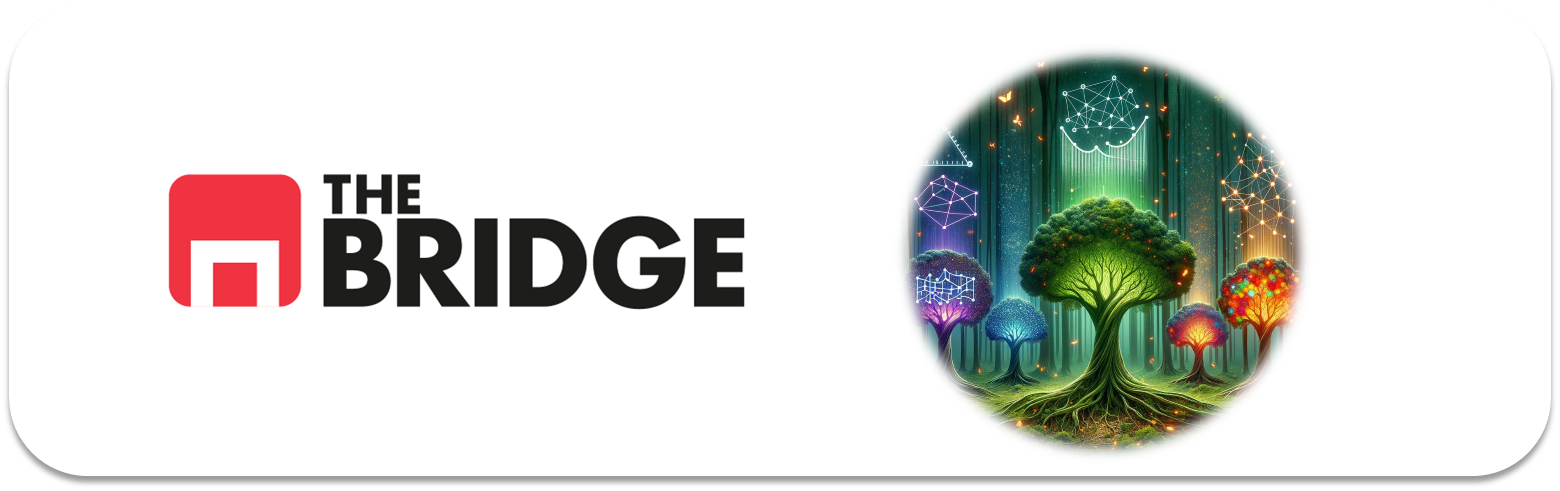

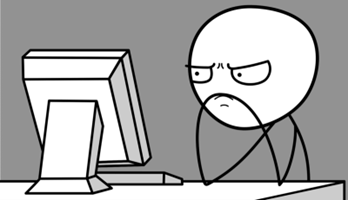

Para ejercitarte y afianzar lo aprendido sobre **Bagging y Boosting**, completa los siguientes ejercicios. Recuerda que necesitarás datos que están en el directorio data que acompaña al notebook (búscalo en el repositorio de ejercicios)
  
La solución a los mismos las tienes ya, intenta no mirarlos de primeras pero no dejes de hacerlo cuando hayas terminado por si te pudieran aportar.

### Ejercicio 0.1

Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler





### Ejercicio 0.2

Carga el dataset conocido como Mnist y vuélcalo en un array en numpy. Ejecuta la siguiente celda:

In [15]:
df = pd.read_csv("./data/mnist_csv", index_col=False)


In [21]:
df

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784,numero
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,7
996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,6
997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,3


In [22]:
array = np.array(df.drop(columns="numero"))

In [23]:
array

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(1000, 784))

### Ejercicio 1

Muestra el contenido del dataset, las primersas 5 filas. Y luego utiliza la función que tienes a continuaicón para mostrar cada instancia de una forma gráfica. Muestra las cinco primeras y el target de las mismas

In [24]:
import matplotlib.pyplot as plt
import numpy as np

def plot_mnist_images(images, bck_white = False):
    """
    Función para mostrar imágenes del dataset MNIST.

    :param images: Array de numpy con múltiples imágenes, cada una de 784 elementos.
    """
    # Número de imágenes
    num_images = len(images)

    # Crear una cuadrícula de subplots
    cols = int(np.sqrt(num_images))
    rows = (num_images // cols) + 1

    fig, axes = plt.subplots(rows, cols, figsize=(cols*2, rows*2))
    axes = axes.flatten()

    for i, ax in enumerate(axes):
        if i < num_images:
            # Convertir cada imagen de 784 elementos a un array 2D de 28x28
            img_matrix = images[i].reshape(28, 28)

            # Mostrar la imagen
            ax.imshow(img_matrix, cmap='gray' if not bck_white else "binary" )

            # Quitar los ejes
            ax.axis('off')
        else:
            ax.axis('off')

    plt.tight_layout()
    plt.show()



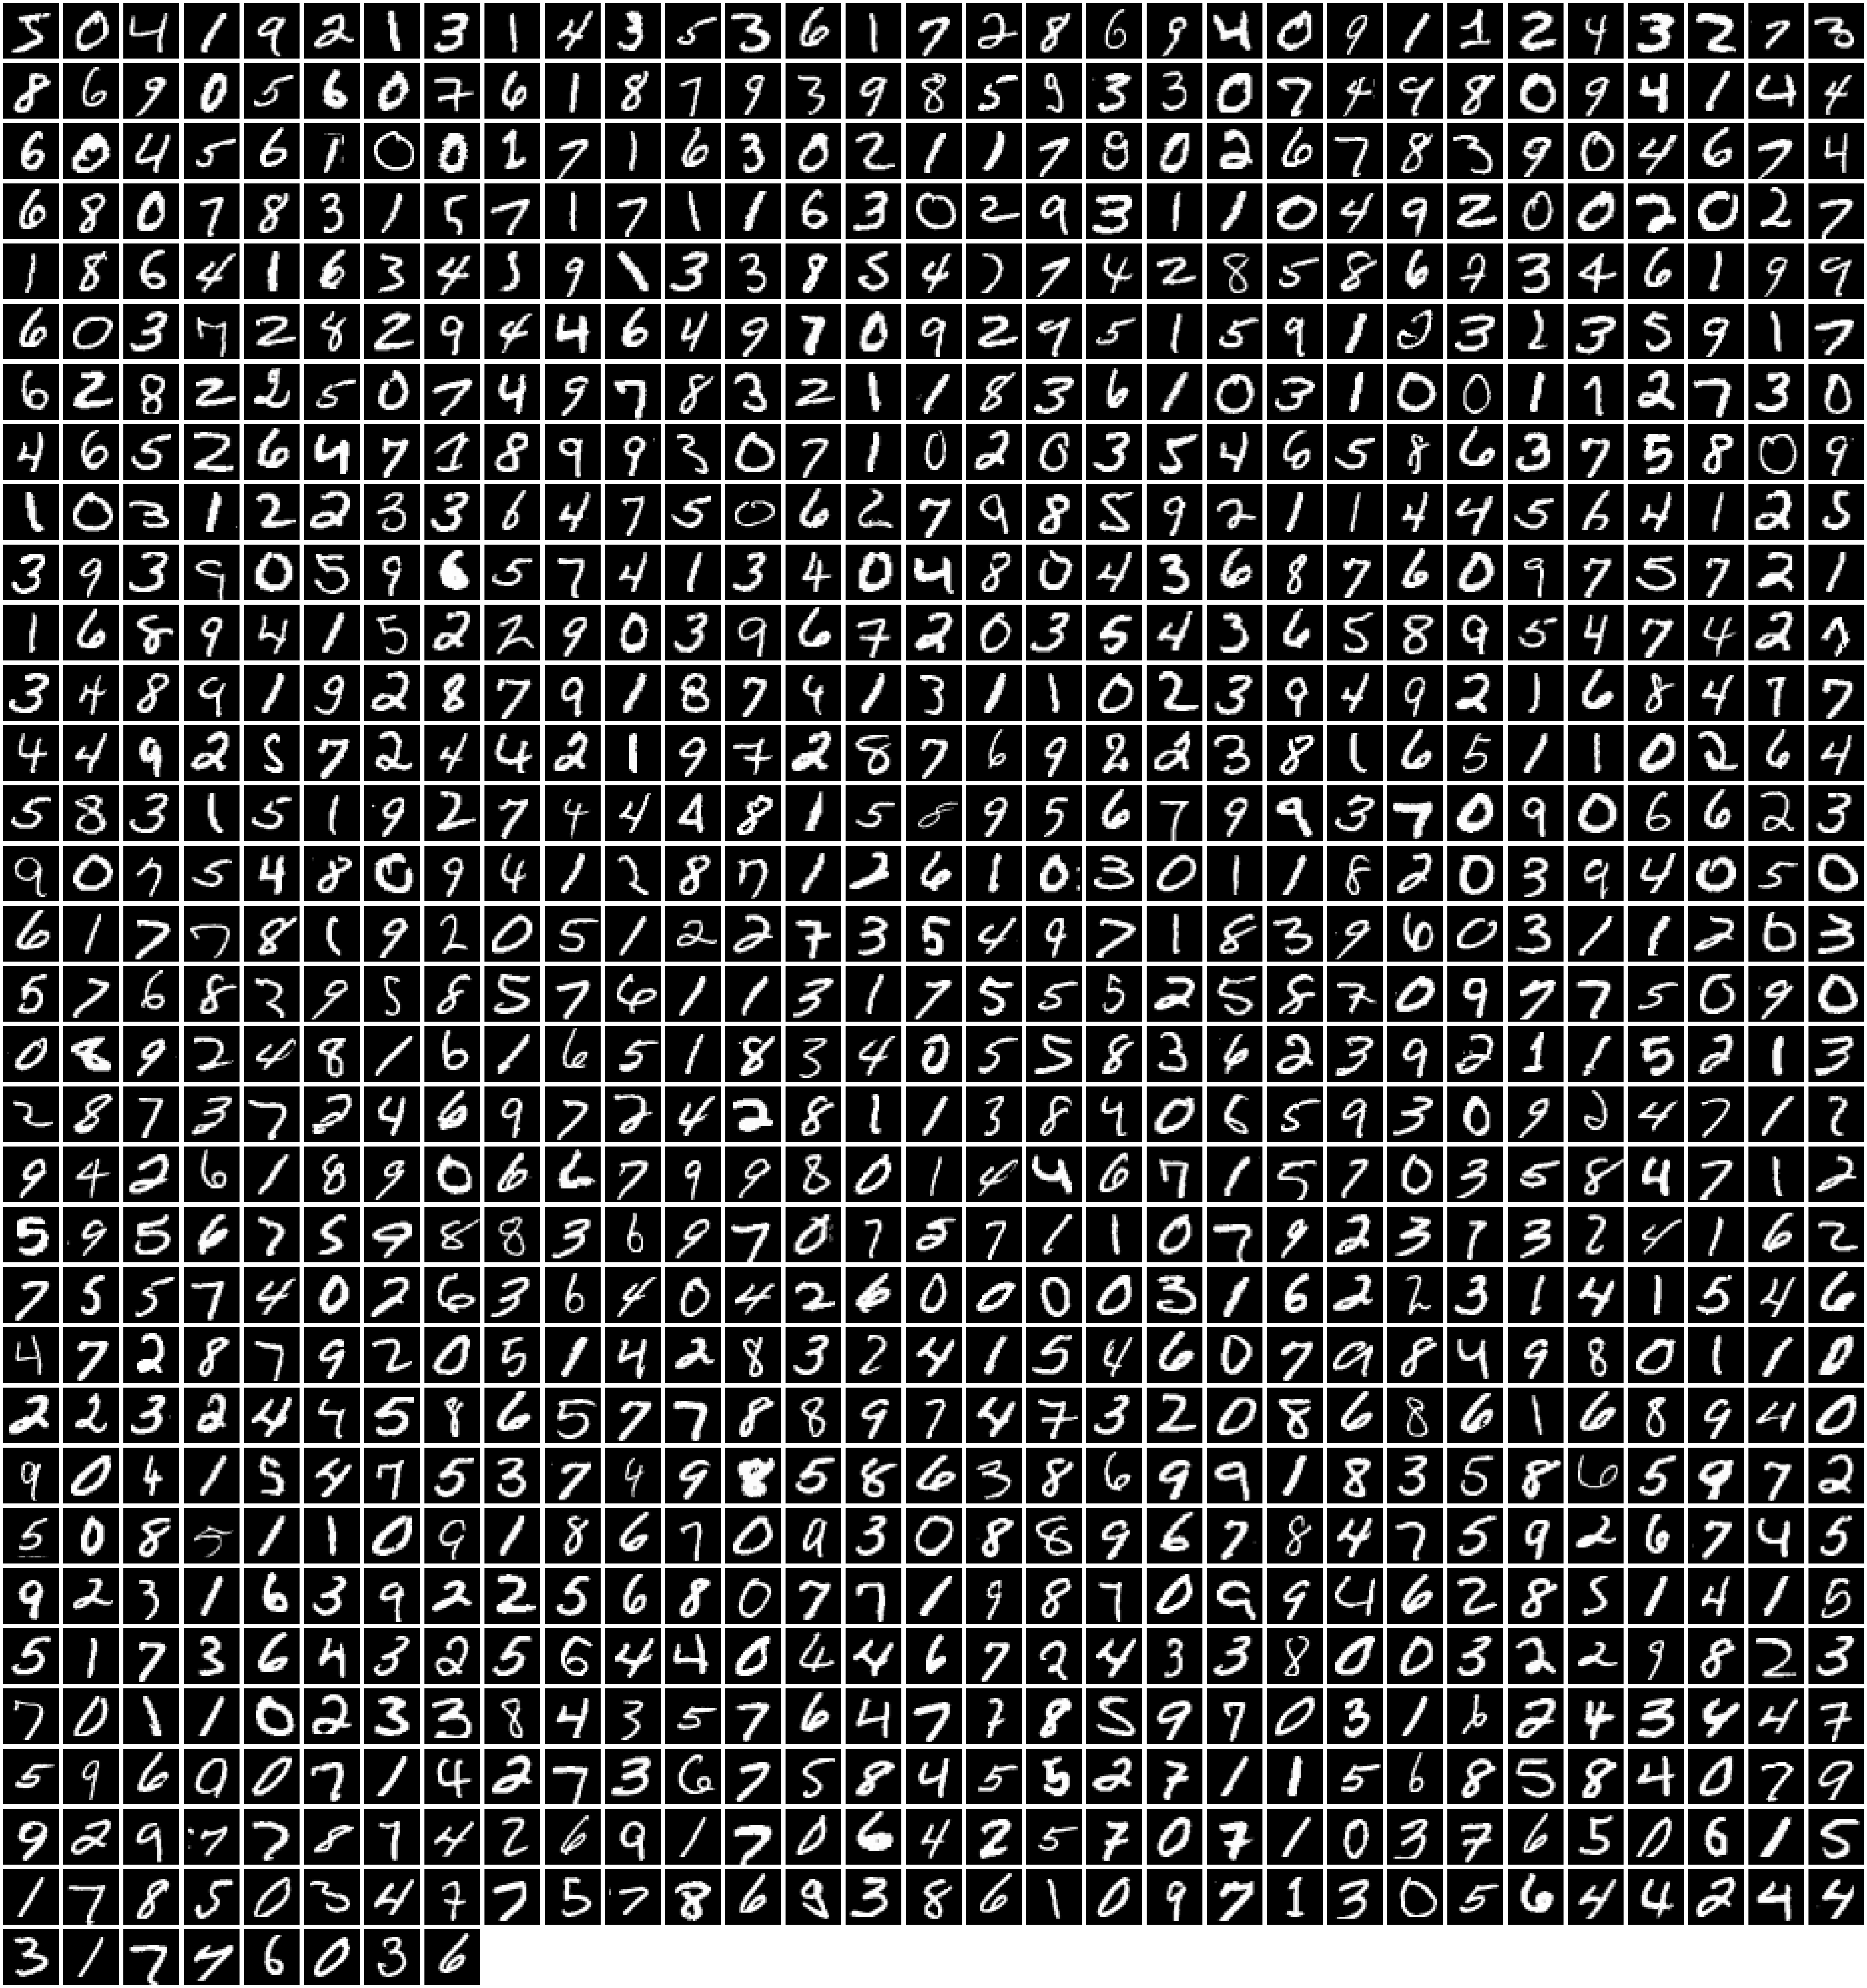

In [25]:
plot_mnist_images(array)

¿Cuántos pixeles tiene de alto y ancho cada imagen? 1?¿


### Ejercicio 2

Separa en train y test. Muestra el número de instancias para cada grupo

In [19]:
df.head()

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784,numero
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9


In [10]:
x_train,x_test,y_train,y_test = train_test_split(df.drop(columns="numero"),df["numero"],train_size = 0.8)


### Ejercicio 3

Entrena un clasificador basado en Random Forest. Haz la predicción sobre los 5 primeros elementos del dataset de train y comprueba visualmente cuánto ha acertado.

In [11]:
from sklearn.ensemble import RandomForestClassifier

In [13]:
rfc = RandomForestClassifier(random_state=1)

In [14]:
rfc.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [27]:
rfc.predict(df.drop(columns="numero").head())

array([5, 0, 4, 1, 9])

### Ejercicio 4

Pruébalo contra test y muestra su informe de clasificación

In [29]:
from sklearn.metrics import classification_report

In [28]:
predictrfc = rfc.predict(x_test)

In [30]:
print(classification_report(y_test,predictrfc))

              precision    recall  f1-score   support

           0       0.89      1.00      0.94        17
           1       0.79      0.96      0.87        24
           2       0.91      0.81      0.86        26
           3       0.95      0.87      0.91        23
           4       0.84      0.89      0.86        18
           5       0.89      0.89      0.89        18
           6       1.00      0.90      0.95        20
           7       0.91      0.87      0.89        23
           8       0.93      0.88      0.90        16
           9       0.75      0.80      0.77        15

    accuracy                           0.89       200
   macro avg       0.89      0.89      0.88       200
weighted avg       0.89      0.89      0.89       200



### Ejercicio 5

Obten la feature importance del modelo pero muéstrala como una imagen para que veamos que píxeles son más importantes (hay tantos coeficientes como píxeles, recuerda). PISTA: Igual puedes usar parte del código de la función anterior o todo.

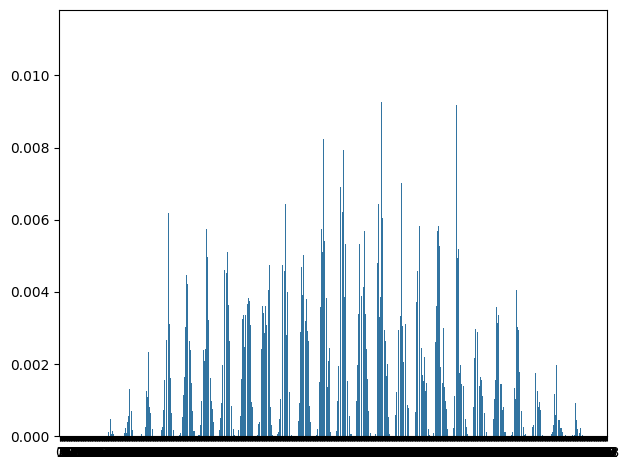

In [34]:
sns.barplot(rfc.feature_importances_)
plt.tight_layout()
plt.show()

### Ejercicio 6 

Entrena ahora un ensamblado basado en el Gradient Boosted Trees de sklearn. Muestra la predicción de los números en las posiciones 20 a 25 de train y su target.

In [35]:
from sklearn.ensemble import GradientBoostingClassifier

In [37]:
gbc = GradientBoostingClassifier()
gbc.fit(x_train, y_train)
gbc.predict(df.drop(columns="numero")[20:25])

array([4, 0, 9, 1, 1])

In [38]:
df["numero"][20:25]

20    4
21    0
22    9
23    1
24    1
Name: numero, dtype: int64

### Ejercicio 7

Pruébalo contra test y muestra su informe de clasificación

In [39]:
predictgbc = gbc.predict(x_test)
print(classification_report(y_test,predictgbc))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        17
           1       0.88      0.96      0.92        24
           2       1.00      0.81      0.89        26
           3       0.84      0.91      0.88        23
           4       0.79      0.83      0.81        18
           5       0.93      0.78      0.85        18
           6       1.00      1.00      1.00        20
           7       0.83      0.83      0.83        23
           8       0.73      0.69      0.71        16
           9       0.53      0.67      0.59        15

    accuracy                           0.85       200
   macro avg       0.85      0.85      0.85       200
weighted avg       0.87      0.85      0.86       200



### Ejercicio 8

Entrena ahora un ensamblado basado en XGBoost. Muestra la predicción de los números en las posiciones 50 a 55 de train y su target.

In [40]:
from xgboost import XGBClassifier

In [41]:
xgbc = XGBClassifier()
xgbc.fit(x_train,y_train)
xgbc.predict(df.drop(columns="numero")[50:55])

array([3, 0, 7, 4, 9])

In [43]:
df["numero"][50:55]

50    3
51    0
52    7
53    4
54    9
Name: numero, dtype: int64

### Ejercicio 9

Pruébalo contra test y muestra su informe de clasificación

In [44]:
predictxgbc = xgbc.predict(x_test)
print(classification_report(y_test,predictxgbc))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        17
           1       0.96      0.96      0.96        24
           2       0.85      0.85      0.85        26
           3       0.90      0.83      0.86        23
           4       0.80      0.89      0.84        18
           5       0.83      0.83      0.83        18
           6       1.00      0.85      0.92        20
           7       0.91      0.87      0.89        23
           8       0.76      0.81      0.79        16
           9       0.67      0.80      0.73        15

    accuracy                           0.87       200
   macro avg       0.87      0.87      0.87       200
weighted avg       0.88      0.87      0.87       200



### Ejercicio 10

Entrena ahora un ensamblado basado en LightGBM. Muestra la predicción de los números en las posiciones 125 a 130 de train y su target.

In [45]:
from lightgbm import LGBMClassifier

In [46]:
lgbm = LGBMClassifier()
lgbm.fit(x_train,y_train)
lgbm.predict(df.drop(columns="numero")[125:130])

array([8, 6, 4, 1, 6])

In [47]:
df["numero"][125:130]

125    8
126    6
127    4
128    1
129    6
Name: numero, dtype: int64

### Ejercicio 11

Pruébalo contra test y muestra su informe de clasificación

In [48]:
predictslgbm = lgbm.predict(x_test)
print(classification_report(y_test,predictslgbm))

              precision    recall  f1-score   support

           0       1.00      0.94      0.97        17
           1       0.88      0.96      0.92        24
           2       0.88      0.88      0.88        26
           3       0.91      0.87      0.89        23
           4       0.84      0.89      0.86        18
           5       0.89      0.94      0.92        18
           6       1.00      0.90      0.95        20
           7       0.87      0.87      0.87        23
           8       0.93      0.81      0.87        16
           9       0.71      0.80      0.75        15

    accuracy                           0.89       200
   macro avg       0.89      0.89      0.89       200
weighted avg       0.89      0.89      0.89       200



### Ejercicio 12

Entrena ahora un ensamblado basado en CatBoost. Muestra la predicción de los números en las posiciones 305 a 310 de train y su target.

In [49]:
from catboost import CatBoostClassifier

In [50]:
cb = CatBoostClassifier()
cb.fit(x_train,y_train)
cb.predict(df.drop(columns="numero")[305:310])

Learning rate set to 0.078231
0:	learn: 2.2010807	total: 265ms	remaining: 4m 24s
1:	learn: 2.1115384	total: 395ms	remaining: 3m 17s
2:	learn: 2.0224272	total: 512ms	remaining: 2m 50s
3:	learn: 1.9431712	total: 638ms	remaining: 2m 38s
4:	learn: 1.8852034	total: 760ms	remaining: 2m 31s
5:	learn: 1.8205580	total: 888ms	remaining: 2m 27s
6:	learn: 1.7406616	total: 1.01s	remaining: 2m 23s
7:	learn: 1.6770017	total: 1.13s	remaining: 2m 20s
8:	learn: 1.6200904	total: 1.26s	remaining: 2m 19s
9:	learn: 1.5665307	total: 1.41s	remaining: 2m 19s
10:	learn: 1.5094280	total: 1.55s	remaining: 2m 19s
11:	learn: 1.4630654	total: 1.7s	remaining: 2m 20s
12:	learn: 1.4203324	total: 1.83s	remaining: 2m 19s
13:	learn: 1.3839245	total: 1.96s	remaining: 2m 18s
14:	learn: 1.3433114	total: 2.08s	remaining: 2m 16s
15:	learn: 1.3063993	total: 2.22s	remaining: 2m 16s
16:	learn: 1.2671566	total: 2.35s	remaining: 2m 15s
17:	learn: 1.2328141	total: 2.47s	remaining: 2m 14s
18:	learn: 1.1956978	total: 2.6s	remaining: 2

array([[7],
       [5],
       [7],
       [2],
       [1]])

In [51]:
df["numero"][305:310]

305    7
306    5
307    7
308    2
309    1
Name: numero, dtype: int64

### Ejercicio 13

Pruébalo contra test y muestra su informe de clasificación

In [52]:
predictcb = cb.predict(x_test)
print(classification_report(y_test,predictcb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        17
           1       0.82      0.96      0.88        24
           2       0.92      0.85      0.88        26
           3       0.95      0.91      0.93        23
           4       0.86      1.00      0.92        18
           5       0.94      0.94      0.94        18
           6       1.00      0.95      0.97        20
           7       0.83      0.87      0.85        23
           8       0.92      0.75      0.83        16
           9       0.86      0.80      0.83        15

    accuracy                           0.91       200
   macro avg       0.91      0.90      0.90       200
weighted avg       0.91      0.91      0.90       200



### Ejercicio 14

A la vista de los resultados, ¿con qué modelo te quedarías?

depende, si tuviera mucho tiempo catboost, en caso contrario ligthgbm   